# VPT Calculations

The purpose of this notebook is to carry out some calculations that apply variational perturbation theory (VPT) on the classic harmonic oscillator with quartic perturbation. The idea behind VPT is covered in the Overleaf doc so I'll skip it here, but the idea is pretty simple: we add and subtract a harmonic term with some fictitious frequency $\Omega$, treat the plus term as part of the unperturbed Hamiltonian (which just shifts the frequency $\omega$ to $\sqrt{\omega^2 + \Omega^2}$ in the regular harmonic oscillator solution), and treat the minus term as part of the perturbation to the Hamiltonian (which includes the quartic term). 

Then simply apply perturbation theory, and then minimize sensitivity w.r.t. the fictitious parameter. By minimizing sensitivity we mean to say that ideally, the derivative of the energy w.r.t. the parameter is zero. But as we will see even in this simple case, we will not find a nontrivial point satisfying this condition always. When this happens, we then make the second derivative zero since that's the next best thing, or we can think of it as minimizing the first derivative. When this is also not available we move onto the third derivative, and so on. 

This notebook has a bunch of stuff and tons of helper functions, so perhaps it is useful to consider a roadmap for what we are dealing with. I will frontload the definition of all the constants and helper functions, and thoroughly comment them. The interested reader should look at these comments to figure out what the functions do. The naming is... accurate-ish but it isn't always the most descriptive.

We will start by doing the most basic thing possible, which is to minimize the ground state energy directly w.r.t. $\Omega$. We will see a nontrivial result for the first order calculation, but the second order calculation isn't so cooperative. Here is where we investigate the second derivatives and such as mentioned above. There's a couple different ways to do this. One way is to perform a grid search, i.e. generate an $\Omega$ vector and find the corresponding energies, and look for zeroes. The accuracy of this sucks and it takes too long to get good accuracy, and there's some other problems with it. There's some cool code but the method itself sucks so feel free to ignore it. 

The other and "more proper" way is to define a function for the energy as a function of $\Omega$ and minimize it using SciPy. This is what I'll do to start things off. Again we'll see first order works and the second order fails, leading us to employ the talents of the first derivative of the second order energy. We'll minimize this instead to find the right value for $\Omega$. 

Once we have the value for $\Omega$ we can do some stuff with it. First of all, obviously put it back in to find the VPT energies. But we can also see how it makes the Hamiltonian look in the unperturbed oscillator basis. To visualize this we'll include a heatmap which looks pretty sick.

WARNING: Stuff below has not been implemented yet.

After that, there'll be some stuff about the relationship between $\Omega$ and $\omega$ because that sounds interesting. Using dimensional analysis it's possible to guess the relationship, but here we'll do things graphically. We'll also see how VPT compares to traditional methods as the coupling constant "g" changes. I'll also recreate everything for higher order energies rather than just the ground state. Probably. 

---

Also, in this notebook we will only cover first and second order perturbation theory. 

First up we just have some basic imports. Numpy because duh, SciPy  to minimize, seaborn for heatmaps, Matplotlib because duh, and tabulate to make some matrices look nice when printing.

In [2]:
import numpy as np
import scipy as sp
import seaborn as sns
import matplotlib.pyplot as plt
from tabulate import tabulate


Below we define some constants. The comments are descriptive enough so I won't harp to much on it here. The helper functions are in the cell below that. Again, pretty self-explanatory with my comments I think.

In [3]:
g = 0.2       # quartic coefficient
m = 1       # mass
w = 1       # supposed to be omega i.e. frequency of harmonic oscillator
hb = 1      # short for hbar

b = 10.0    # integral upper bound for Gauss-Legendre quadrature
a = -10.0   # integral lower bound for Gauss-Legendre quadrature (G-L Q)

c1 = (b-a)/2    # these two helper variables are convenient to calculate change of interval for G-L Q
c2 = (b+a)/2

samples, weights = np.polynomial.legendre.leggauss(99)      # G-L Q sample points & weights


In [ ]:
#the wavefunction that solves the unperturbed Hamiltonian
def wavefunction(n, x, Omega):
    freq = np.sqrt(w**2 + Omega**2)
    xi = x * np.sqrt(m*freq/hb)
    return np.exp(-(xi**2)/2) * (m*freq /(np.pi*hb))**(1/4) * ((2**n)*sp.special.factorial(n))**(-1/2) * sp.special.eval_hermite(n, xi)

#the second derivative of the above wavefunction w.r.t. x. I'm just using a central difference formula here. 
def dd_wavefunction(n, x, Omega):
    h=1e-4
    return (wavefunction(n, x+h, Omega) - 2*wavefunction(n, x, Omega) + wavefunction(n, x-h, Omega)) / h**2

#the action of the unperturbed Hamiltonian on the unperturbed wavefunctions
def H0psi(n, x, Omega):
    return -(hb**2)/(2*m) * dd_wavefunction(n, x, Omega) + (1.0/2)*m*(Omega**2 + w**2)*(x**2) * wavefunction(n, x, Omega)

#perturbation to the Hamiltonian
def H1(x, Omega):
    return g*(x**4) - (1.0/2)*m*(Omega**2)*(x**2)

# transition amplitude, i.e. the integrand of the energy expectation value integral
def trans_amp(n1, n2, x, Omega):
    return wavefunction(n2, x, Omega) * H0psi(n1, x, Omega) + trans_amp_pert(n1, n2, x, Omega)

#same as trans_amp but for the perturbation alone. There is a use for this alone (see E1, E2 below) which is why I've separated it. 
def trans_amp_pert(n1, n2, x, Omega):
    return wavefunction(n1, x, Omega) * H1(x, Omega) * wavefunction(n2, x, Omega)

#zeroth order energy, i.e. energy of the unperturbed Hamiltonian
def E0(n, Omega):
    return (n*1.0 + 1.0/2)*hb*np.sqrt(w**2 + Omega**2)

# The following two functions are classic perturbation theory results, nothing special. The integrals are evaluated using Gauss-Legendre quadrature.

#first order energy correction as a result of the quartic perturbation
def E1(n, Omega):
    return c1 * np.dot(weights, trans_amp_pert(n, n, c1*samples + c2, Omega))

#second order energy correction due to quartic perturbation
def E2(n, Omega):
    E_2 = 0
    # with some more analysis you can show that you can skip every other term, but we'll keep it general
    for i in range(0, n + 5):
        if (i == n):
            continue 

        integral = c1 * np.dot(weights, trans_amp_pert(n, i, c1*samples + c2, Omega))
        E_2 += integral**2 / (E0(n, Omega) - E0(i, Omega))

    return E_2

# first order total energy. This is the function we will be minimizing to get the Omega value. 
def ground1(Omega):
    return E0(0, Omega) + E1(0, Omega)

# second order total energy. We'll minimize this and show that it gives squat. 
def ground2(Omega):
    return E0(0, Omega) + E1(0, Omega)  + E2(0, Omega)

# just a central difference derivative of the second order total energy. It's convenient. 
def first_derivative_2o(Omega):
    h=1e-5
    return (ground2(Omega + h) - ground2(Omega - h)) / (2*h)


As promised earlier I'll start by using the naive method of finding VPT solutions to the fictitious parameter, which is to straight up minimize the corrected energies w.r.t. $\Omega$. 

As you can see below, we get a nice non-trivial solution for the first order energy. Interestingly it's exactly what you'd get if you use the variational method using a plain Gaussian.

In [90]:
Omega_1o = sp.optimize.minimize(ground1, x0=[1.0]).x[0]

print(Omega_1o)                    # this is Omega
print(ground1(Omega_1o))        # Here I'm just plugging it back in to find the energy

0.9360018408390476
0.6049007479976076


The next cell is a solution for the second order energy. It's trivial. So our naive method has failed because in truth there is no point with zero derivative outside of $\Omega = 0$. This is where we need to employ minimimum sensitivity. 

In [91]:
Omega_2o = sp.optimize.minimize(ground2, x0=[1.0]).x[0]

print(Omega_2o)                    # again this is Omega
print(ground2(Omega_2o))           # again just finding the energy

-1.538637674024625e-08
0.5449999999999999


To do this I've defined the convenient helper function that finds the first derivative of the second order energy. We will minimize this function instead, and find that it does get pretty close to zero, but not quite. This corresponds also to setting the second derivative to zero, but in general we want to minimize the first derivative among inflection points anyway so I guess this kills two birds with one stone. In this case we find there is a solution. If there wasn't one we'd have to go digging into higher order derivatives and stuff. 

In [92]:
Omega_2o = sp.optimize.minimize(first_derivative_2o, x0=[1.0]).x[0]

print(Omega_2o)                     # Omega
print(ground2(Omega_2o))            # Energy

1.070566753534574
0.6024386591749555


Here I'm going to go ahead and get started on the heatmaps for the Hamiltonian, since we have the values for the VPT parameter. We can retroactively plug it back into every function to get the Hamiltonian, and the wavefunctions. In this case the integrand I need is captured by trans_amp already, so I just integrate that. We can also save some time by noting that the matrix form of $\hat{H}_1$ is going to be symmetric, so it goes from $n^2$ to $\binom{n}{2} + n$ integrals to calculate which is somewhat less. 

In [93]:
size = 13
energy_matrix1 = np.zeros((size, size))

for i in range(size):
    for j in range(i, size):
        integral = c1 * np.dot(weights, trans_amp(i, j, c1*samples + c2, 0))

        energy_matrix1[i][j] = integral
        energy_matrix1[j][i] = integral


table = tabulate(np.round(energy_matrix1, decimals=4), tablefmt="fancy_grid")

print(table)

╒═════════╤═════════╤═════════╤═════════╤═════════╤═════════╤═════════╤═════════╤═════════╤═════════╤═════════╤═════════╤═════════╕
│  0.65   │  0      │  0.4243 │ -0      │  0.2449 │  0      │  0      │  0      │ -0      │ -0      │  0      │ -0      │ -0      │
├─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┤
│  0      │  2.25   │  0      │  1.2247 │  0      │  0.5477 │  0      │  0      │ -0      │ -0      │  0      │  0      │  0      │
├─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┤
│  0.4243 │  0      │  4.45   │  0      │  2.4249 │ -0      │  0.9487 │  0      │  0      │ -0      │  0      │  0      │ -0      │
├─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┤
│ -0      │  1.2247 │  0      │  7.25   │ -0      │  4.0249 │ -0      │  1.4

In [94]:
energy_matrix2 = np.zeros((size, size))

for i in range(size):
    for j in range(i, size):
        integral = c1 * np.dot(weights, trans_amp(i, j, c1*samples + c2, Omega_1o))

        energy_matrix2[i][j] = integral
        energy_matrix2[j][i] = integral

table = tabulate(np.round(energy_matrix2, decimals=4), tablefmt="fancy_grid")

print(table)


╒═════════╤═════════╤═════════╤═════════╤═════════╤═════════╤═════════╤═════════╤═════════╤═════════╤═════════╤═════════╤═════════╕
│  0.6049 │ -0      │ -0      │ -0      │  0.1306 │ -0      │ -0      │ -0      │  0      │  0      │ -0      │ -0      │  0      │
├─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┤
│ -0      │  1.9746 │  0      │  0.2611 │  0      │  0.2919 │  0      │ -0      │  0      │ -0      │ -0      │  0      │  0      │
├─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┤
│ -0      │  0      │  3.6641 │ -0      │  0.7386 │  0      │  0.5057 │ -0      │ -0      │  0      │  0      │ -0      │ -0      │
├─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┤
│ -0      │  0.2611 │ -0      │  5.6735 │ -0      │  1.4302 │ -0      │  0.7

In [95]:
energy_matrix3 = np.zeros((size, size))

for i in range(size):
    for j in range(i, size):
        integral = c1 * np.dot(weights, trans_amp(i, j, c1*samples + c2, Omega_2o))

        energy_matrix3[i][j] = integral
        energy_matrix3[j][i] = integral


table = tabulate(np.round(energy_matrix3, decimals=4), tablefmt="fancy_grid")

print(table)


╒═════════╤═════════╤═════════╤═════════╤═════════╤═════════╤═════════╤═════════╤═════════╤═════════╤═════════╤═════════╤═════════╕
│  0.6068 │  0      │ -0.0789 │ -0      │  0.1141 │  0      │  0      │  0      │ -0      │  0      │  0      │ -0      │ -0      │
├─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┤
│  0      │  1.9601 │ -0      │  0.0916 │  0      │  0.2552 │  0      │ -0      │  0      │  0      │ -0      │  0      │  0      │
├─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┤
│ -0.0789 │ -0      │  3.5931 │ -0      │  0.4524 │  0      │  0.442  │ -0      │  0      │ -0      │  0      │  0      │ -0      │
├─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┼─────────┤
│ -0      │  0.0916 │ -0      │  5.5056 │  0      │  1.0008 │ -0      │  0.6

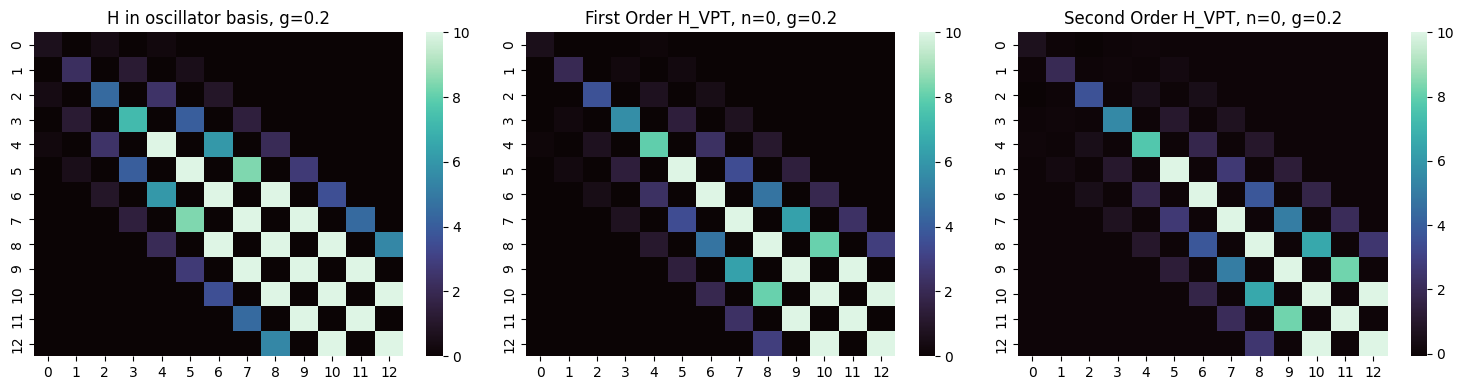

In [96]:
fig = plt.figure(figsize=(15, 4))
ax1 = fig.add_subplot(1, 3, 1)
ax2 = fig.add_subplot(1, 3, 2)
ax3 = fig.add_subplot(1, 3, 3)
ax1.set_title('H in oscillator basis, g=0.2')
ax2.set_title('First Order H_VPT, n=0, g=0.2')
ax3.set_title('Second Order H_VPT, n=0, g=0.2')
sns.heatmap(energy_matrix1, ax=ax1, vmax = 10, cmap='mako')
sns.heatmap(energy_matrix2, ax=ax2, vmax = 10, cmap ='mako')
sns.heatmap(energy_matrix3, ax=ax3, vmax = 10, cmap = 'mako')

fig.tight_layout()
plt.show()


In [97]:
# include other stuff about higher order energies, omega vs Omega, coupling constant graph

The stuff below here is back when I was performing a grid search to find the zeroes and stuff, and I've now moved onto an optimizer which is above. I'll probably end up exporting the code below to another file anyway. 

In [ ]:
# find the k-th order derivative of v1 w.r.t. v2, where v1 and v2 are vectors. 
# Note that this function uses recursion. which will fail if k < 0 resulting in an infinite loop.
def v_derivative(v1, v2, k):
    if(k == 0):                 # base case
        return v1
    
    vd = np.zeros_like(v1, dtype=np.float64)

    for i in range(1, len(vd) - 1):
        if(v2[i+1] - v2[i-1] != 0):
            vd[i] = (v1[i+1] - v1[i-1])/(v2[i+1] - v2[i-1])     # classic central difference formula

    return v_derivative(vd, v2, k-1)        # recursive call

#find the zeroes of the k-th order derivative of yvec w.r.t. xvec, where the derivative points are rounded to precision decimals.
def deriv_zeroes(xvec, yvec, k, precision):
    vector = v_derivative(yvec, xvec, k)
    rounded_vec = np.round(vector, decimals=precision)
    zero_points = np.where(rounded_vec == 0)[0][1:-1]           # derivative endpointsa are defined as zero, just remove them

    return zero_points

Now we do the less naive way, using the derivatives and finding their zeroes when available. I'm being a bit sloppy with naming but xaxis is supposed to be a list of $\Omega$ values and yaxis is supposed to be the corresponding energies. I don't want to break the code now messing with the names, so we're going to stick with it.

For the first order calc we could have just done the straight VPT calculation without bothering with the helper functions but I think it's better to generalize using them anyway so here goes. Firstly I set it up using the function "ground1" and not "ground2", since ground1 is to find the ground state energy to the first perturbative order. Nothing special in just setting up the x and y vectors. Next, we figure out where all the zeroes are for the first derivative. Recall we want this to be zero somewhere. Luckily for first order, the first derivative already contains such a zero, as you can see below. 

For the precision parameter, I just kept increasing it until I stopped seeing a bunch of duplicates in and around the actual points. Finally we can just plug in the zeroes we see back into the energy functions that have $\Omega$ as a parameter to get the energy we're looking for. This is in the last code blurb before the second order stuff begins.

As you can see in the output of this block, the predicted energy is ~0.6049. Interestingly this is actually exactly what you get if you perform a variational calculation using the Gaussian as a guess. You can see this in the corresponding Jupyter notebook in this file system.

In [305]:
xaxis = np.arange(-2, 2, 0.0001)
yaxis = np.array([ground1(xaxis[i]) for i in range(len(xaxis))])

In [309]:
pts = np.round(deriv_zeroes(xaxis, yaxis, 1, 5), decimals = 3)
zero_xpts = xaxis[pts]

print(zero_xpts)

[-9.36000000e-01 -2.20268248e-13  9.36000000e-01]


In [310]:
print(ground1(0.936))

0.6049007479979343


Now we begin doing the second order stuff where it becomes slightly less trivial. This time we can play around with the precision and note that unless we bring it down to like 2 decimal places, there are no zeroes anywhere in the first derivative. It's not sensible to accept those zeroes, I would think, since our precision in the construction of $\Omega$ values is in the order of ten-thousandths. So I conclude that there are no zeroes in the first derivative. You can actually see this directly on a graph, or if you further increase the precision of the $\Omega$ values, but I won't demonstrate that since it's kind of ugly and pretty easy to do anyway. 

To look for minimum sensitivity the next step is to try to find zeroes of the next derivative order, so we move onto the second derivative. This time we see that there are actually non-trivial answers, and further even playing around with the precision there's a couple duplicates to parse out. This is part of what makes writing a generalized function a little difficult for me, since these kinds of caveats can't really be predicted, at least to my knowledge, and it's just easier for me to look at it and discern that there's duplicates.

It's worth noting there are two nontrivial answers: $\Omega \approx 1.0706,  0.3335$. To figure out which one to use, I also evaluate the first order derivative there. The point with the smaller lower order derivative wins the low sensitivity contest and is elected as the winner, and then as usual we just plug it back into the energy function to find the second order corrected energy. Whether you use 1.0706 or 1.0707 is sort of irrelevant since you realistically shouldn't be rounding it farther than the third decimal, in which case both give the same answer of $E^{(2)} \approx 0.6024$. Again there's an interesting parallel in that this gives roughly the same answer as the variational method if we picked a guess wavefunction of an extended Gaussian, i.e. a Gaussian but the $x^2$ term in the exponent is added on to an $x^4$ term too. 

This last part also plays a role in my inability to write a completely automatic function for this entire process, since it requires retroactively going back to the lower order derivatives and seeing which ones corresponding to the zeroes of higher order derivatives, are the most sensitive. Of course there's a way to do it, but it's not entirely clear to me that, in all situations, a clear less sensitive option will appear or how to gauge sensitivity  when the order of derivative we're looking at is like 4 or 5, and details on sensitivity then depend on the 3-4 lower derivatives. So I've elected to keep this part manual for now.

In [8]:
xaxis = np.arange(-2, 2, 0.0001)
yaxis = np.array([ground2(xaxis[i]) for i in range(len(xaxis))])

In [315]:
pts = np.round(deriv_zeroes(xaxis, yaxis, 1, 4), decimals = 3)
zero_xpts = xaxis[pts]

print(zero_xpts)

[-2.20268248e-13]


In [318]:
pts = np.round(deriv_zeroes(xaxis, yaxis, 2, 4), decimals = 3)
zero_xpts = xaxis[pts]

print(zero_xpts)
print(v_derivative(yaxis, xaxis, 1)[pts])

[-1.0707 -1.0706 -0.3335  0.3335  1.0706  1.0707]
[-0.00341346 -0.00341346 -0.10542122  0.10542122  0.00341346  0.00341346]


In [323]:
print(ground2(1.0706))

0.6024387726603617


Stuff below is just testing stuff, not serious. But there's some nice illustrations on what the functions and derivatives look like if you can decipher what I've written. 

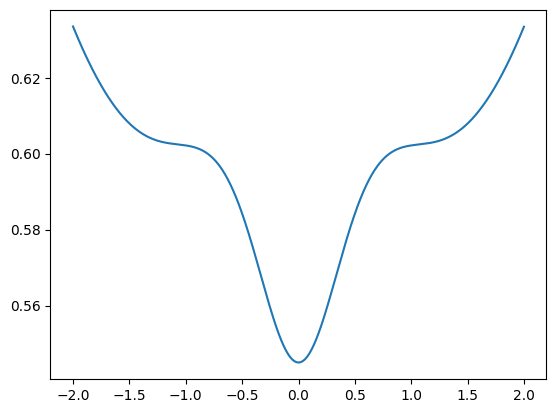

In [220]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)

ax.plot(xaxis, yaxis)

In [13]:
deriv =  v_derivative(yaxis, xaxis, 1)
dderiv = v_derivative(deriv, xaxis, 1)

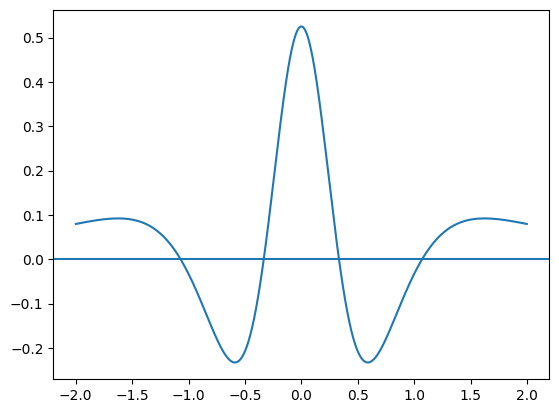

In [14]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)

ax.plot(xaxis[10:-10], dderiv[10:-10])
#ax.plot(xaxis[10:-10], deriv[10:-10])
ax.axhline(0)
